In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
sales = pd.read_csv(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\Online_Sales.csv")
customers = pd.read_excel(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\CustomersData.xlsx")
coupon = pd.read_csv(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\Discount_Coupon.csv")
marketing = pd.read_csv(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\Marketing_Spend.csv")
tax = pd.read_excel(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\4. Capstone Case Study - Finding-Marketing-Insights\Datasets\Tax_amount.xlsx")

In [3]:
sales.columns = (
    sales.columns
    .str.strip()
    .str.replace(' ','_')
)

In [4]:
sales['Transaction_Date'] = pd.to_datetime(
    sales['Transaction_Date'].astype(str),
    format='%Y%m%d'
)

In [5]:
sales['Purchase_Month'] = (
    sales['Transaction_Date']
    .dt.to_period('M')
)

In [6]:
cohort = sales.groupby('CustomerID')[
    'Purchase_Month'
].min()

sales['Cohort_Month'] = sales[
    'CustomerID'
].map(cohort)

In [7]:
sales['Cohort_Index'] = (
    (sales['Purchase_Month'].dt.year -
     sales['Cohort_Month'].dt.year) * 12
    +
    (sales['Purchase_Month'].dt.month -
     sales['Cohort_Month'].dt.month)
    + 1
)

In [8]:
cohort_data = (
    sales.groupby(
        ['Cohort_Month','Cohort_Index']
    )['CustomerID']
    .nunique()
    .reset_index()
)

In [9]:
cohort_table = cohort_data.pivot(
    index='Cohort_Month',
    columns='Cohort_Index',
    values='CustomerID'
)

In [10]:
cohort_table.head()

Cohort_Index,1,2,3,4,5,6,7,8,9,10,11,12
Cohort_Month,,,,,,,,,,,,
2019-01,215.0,13.0,24.0,34.0,23.0,44.0,35.0,47.0,23.0,28.0,20.0,34.0
2019-02,96.0,7.0,9.0,16.0,17.0,22.0,19.0,15.0,12.0,11.0,16.0,NaN
2019-03,177.0,18.0,35.0,25.0,32.0,33.0,22.0,22.0,15.0,19.0,NaN,NaN
2019-04,163.0,14.0,24.0,24.0,18.0,15.0,10.0,16.0,12.0,NaN,NaN,NaN
2019-05,112.0,12.0,9.0,13.0,10.0,13.0,14.0,8.0,NaN,NaN,NaN,NaN


In [11]:
cohort_size = cohort_table.iloc[:,0]

In [12]:
retention = cohort_table.divide(
    cohort_size,
    axis=0
)

In [13]:
retention = retention * 100

In [14]:
retention.round(2)

Cohort_Index,1,2,3,4,5,6,7,8,9,10,11,12
Cohort_Month,,,,,,,,,,,,
2019-01,100.0,6.05,11.16,15.81,10.70,20.47,16.28,21.86,10.70,13.02,9.30,15.81
2019-02,100.0,7.29,9.38,16.67,17.71,22.92,19.79,15.62,12.50,11.46,16.67,NaN
2019-03,100.0,10.17,19.77,14.12,18.08,18.64,12.43,12.43,8.47,10.73,NaN,NaN
2019-04,100.0,8.59,14.72,14.72,11.04,9.20,6.13,9.82,7.36,NaN,NaN,NaN
2019-05,100.0,10.71,8.04,11.61,8.93,11.61,12.50,7.14,NaN,NaN,NaN,NaN
2019-06,100.0,14.60,16.06,8.76,8.03,10.22,8.03,NaN,NaN,NaN,NaN,NaN
2019-07,100.0,13.83,4.26,6.38,11.70,9.57,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,100.0,10.37,11.11,7.41,5.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,100.0,7.69,3.85,2.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


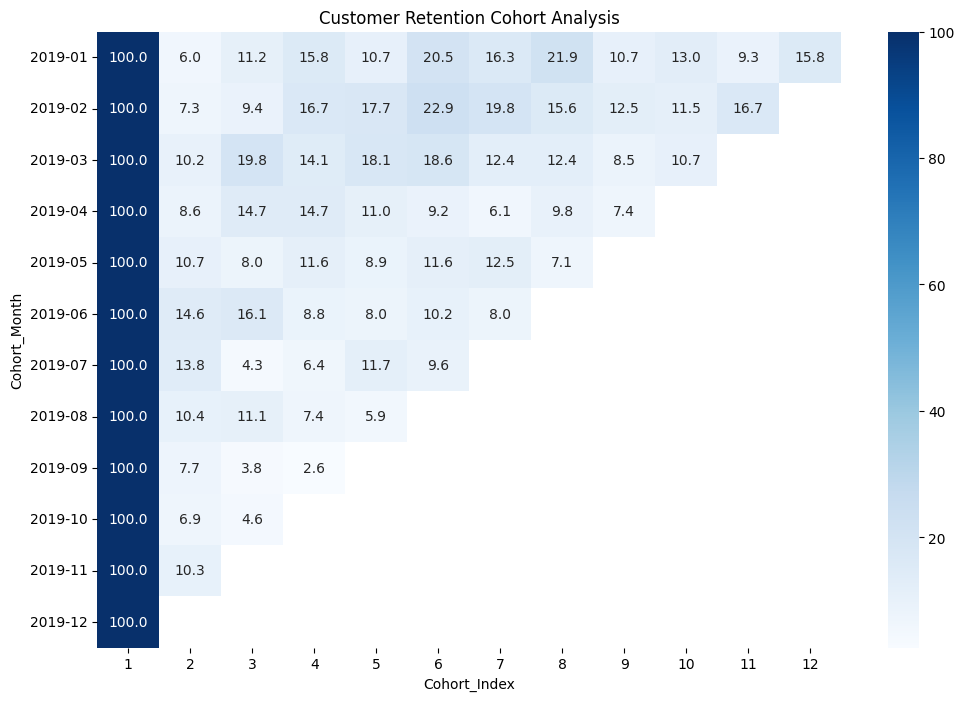

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Customer Retention Cohort Analysis')

plt.show()

In [16]:
retention[2].sort_values(
    ascending=False
)

Cohort_Month
2019-06    14.598540
2019-07    13.829787
2019-05    10.714286
2019-08    10.370370
2019-11    10.294118
2019-03    10.169492
2019-04     8.588957
2019-09     7.692308
2019-02     7.291667
2019-10     6.896552
2019-01     6.046512
2019-12          NaN
Freq: M, Name: 2, dtype: float64

In [17]:
avg_retention = retention.iloc[:,1:].mean(
    axis=1
)

avg_retention.sort_values(
    ascending=False
)

Cohort_Month
2019-02    15.000000
2019-03    13.873195
2019-01    13.742072
2019-06    10.948905
2019-11    10.294118
2019-04    10.199387
2019-05    10.076531
2019-07     9.148936
2019-08     8.703704
2019-10     5.747126
2019-09     4.700855
2019-12          NaN
Freq: M, dtype: float64

In [18]:
best_cohort = avg_retention.idxmax()

print(best_cohort)

2019-02


In [19]:
retention.to_csv(
    'cohort_retention_analysis.csv'
)